In [1]:
source('MS0_Libraries.r')

[1] "/ictstr01/home/icb/bhavishya.nelakuditi/miniconda3/envs/my_jupyter_env/lib/R/library/"


Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘tibble’ was built under R version 4.3.3”
Warning message:
“package ‘purrr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.3”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
Warning message:
“package ‘lubridate’ was built under R version 4.3.3”
── Attaching core tidyverse packages ──────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
“package ‘backports’ w

In [2]:
library(survival)
library(survminer)


Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




In [3]:

library(rms)

Loading required package: Hmisc


Attaching package: ‘Hmisc’


The following object is masked from ‘package:MOFA2’:

    impute


The following objects are masked from ‘package:dplyr’:

    src, summarize


The following objects are masked from ‘package:base’:

    format.pval, units




In [4]:
path = "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/input_data/hazard_cox.csv"
sample_data = read.csv(path)

rownames(sample_data) = sample_data$sample_id
sample_data

,sample_id,catecholamines_days,catecholamines,catecholamines_days_14,catecholamines_14
,<chr>,<dbl>,<int>,<dbl>,<int>
KS5.1,KS5.1,24.00,1,14.00,0
KS6.1,KS6.1,19.00,0,14.00,0
KS13.1,KS13.1,16.00,1,14.00,0
KS15.1,KS15.1,16.00,0,14.00,0
KS34.1,KS34.1,16.00,1,14.00,0
KS17.1,KS17.1,12.00,1,12.00,1
KS3.1,KS3.1,9.00,1,9.00,1
KS9.1,KS9.1,8.00,1,8.00,1
KS25.1,KS25.1,8.00,1,8.00,1


In [5]:
surv_obj <- Surv(time = sample_data$catecholamines_days, event = sample_data$catecholamines)
surv_obj

 [1] 24.00  19.00+ 16.00  16.00+ 16.00  12.00   9.00   8.00   8.00   7.00 
[11]  7.00+  6.00   6.00+  6.00   5.50   5.00   5.00   5.00   5.00   3.00 
[21]  2.75   2.75   2.25   2.00+  2.00   2.00   1.50+  1.00   1.00   0.50+

In [6]:

# Replace with the path to your HDF5 file
hdf5_file_path <- "/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/results/03_results/03_MOFA_MODEL_CGS_v3_MOFA.hdf5"

MOFAobject <- load_model(hdf5_file_path)


In [7]:
Z3 <- get_factors(MOFAobject)[[1]]
Z3 = Z3[rownames(sample_data),]

In [8]:
Z3

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,Factor11,Factor12,Factor13
KS5.1,0.45735292,-1.3759116,-1.187373979,-0.76904259,-1.23797308,0.028882157,-0.46318466,-0.387995878,-0.45226856,-0.39964627,-0.07083247,-0.508878736,0.53543327
KS6.1,-1.09241405,0.1895515,-1.466273185,0.02888548,-0.51428955,0.452640392,0.02716668,-0.636333462,0.03394731,-0.29720311,-0.04194084,0.227383635,-0.28063392
KS13.1,-1.34316591,2.8188848,-0.328735668,-0.51174396,-0.17110475,-0.345929546,-0.77788595,-0.281478267,0.06260042,0.17384307,0.08121828,0.014549978,0.07503035
KS15.1,3.20940866,-0.7404158,-0.642894885,0.01262543,0.32636210,-0.847694822,0.05039445,0.002957716,0.11883477,0.04949076,0.37562416,0.313141791,-0.13562731
KS34.1,-1.05043650,1.4015735,0.135153422,-0.58774779,-0.31006477,-0.019223818,-0.39402588,-0.554087479,0.32027951,0.10495809,-0.17470063,0.107214609,-0.24252347
KS17.1,-0.69057391,1.2028090,-0.657462492,0.40024702,-0.27853823,0.004124337,-0.31484296,0.038405418,-0.33051088,0.04712029,0.33069769,-0.012054353,0.15226303
KS3.1,-1.09637832,0.5956438,-1.306050708,0.36298385,-0.74814601,-0.132219431,0.34942434,-0.304145192,0.01476078,0.09446782,0.28042469,-0.054233196,-0.12828674
KS9.1,-2.05833819,-0.9389598,-1.010321249,0.72846877,-0.14812313,0.014646059,0.16094614,0.187296164,0.41416143,-0.15211027,-0.36473599,0.981421608,-0.60790268
KS25.1,-0.45839864,-1.2742449,0.114817937,0.23045114,0.67152968,-0.741823401,0.33933554,1.036443877,-0.26515199,-0.02792499,0.12527068,-0.198001901,0.14263736
KS11.1,-1.20279512,-0.7874092,-1.007681802,-0.35558197,-0.08853537,-0.282747660,-0.77031785,1.929472083,0.11560659,0.09861224,-0.40840485,0.471869748,0.18404815


In [9]:
df <- data.frame(
  time = sample_data$catecholamines_days,
  event = sample_data$catecholamines,
  Factor3 = Z3[, "Factor3"]
)

print(df)
# Determine the optimal cutpoint for Factor 1
cut <- median(df$Factor3)

cut

        time event      Factor3
KS5.1  24.00     1 -1.187373979
KS6.1  19.00     0 -1.466273185
KS13.1 16.00     1 -0.328735668
KS15.1 16.00     0 -0.642894885
KS34.1 16.00     1  0.135153422
KS17.1 12.00     1 -0.657462492
KS3.1   9.00     1 -1.306050708
KS9.1   8.00     1 -1.010321249
KS25.1  8.00     1  0.114817937
KS11.1  7.00     1 -1.007681802
KS16.1  7.00     0 -0.075431838
KS7.1   6.00     1 -0.311226379
KS14.1  6.00     0 -1.346515776
KS22.1  6.00     1  0.312913986
KS35.1  5.50     1  0.521406259
KS2.1   5.00     1 -0.940900613
KS4.1   5.00     1 -0.296756992
KS20.1  5.00     1 -1.068381104
KS33.1  5.00     1  0.011332426
KS12.1  3.00     1  0.066344577
KS27.1  2.75     1  0.692711411
KS31.1  2.75     1  0.307330200
KS29.1  2.25     1  0.707519599
KS10.1  2.00     0 -0.860438329
KS32.1  2.00     1 -0.046885912
KS36.1  2.00     1  0.009453051
KS24.1  1.50     0  1.272521726
KS8.1   1.00     1 -0.756351328
KS21.1  1.00     1 -0.586509814
KS18.1  0.50     0  0.001032289


[1] -0.3039917

        time event      Factor3 FactorCluster
KS5.1  24.00     1 -1.187373979         FALSE
KS6.1  19.00     0 -1.466273185         FALSE
KS13.1 16.00     1 -0.328735668         FALSE
KS15.1 16.00     0 -0.642894885         FALSE
KS34.1 16.00     1  0.135153422          TRUE
KS17.1 12.00     1 -0.657462492         FALSE
KS3.1   9.00     1 -1.306050708         FALSE
KS9.1   8.00     1 -1.010321249         FALSE
KS25.1  8.00     1  0.114817937          TRUE
KS11.1  7.00     1 -1.007681802         FALSE
KS16.1  7.00     0 -0.075431838          TRUE
KS7.1   6.00     1 -0.311226379         FALSE
KS14.1  6.00     0 -1.346515776         FALSE
KS22.1  6.00     1  0.312913986          TRUE
KS35.1  5.50     1  0.521406259          TRUE
KS2.1   5.00     1 -0.940900613         FALSE
KS4.1   5.00     1 -0.296756992          TRUE
KS20.1  5.00     1 -1.068381104         FALSE
KS33.1  5.00     1  0.011332426          TRUE
KS12.1  3.00     1  0.066344577          TRUE
KS27.1  2.75     1  0.692711411   

Call: survfit(formula = Surv(time, event) ~ FactorCluster, data = df)

                     n events median 0.95LCL 0.95UCL
FactorCluster=FALSE 15     11      8    6.00      NA
FactorCluster=TRUE  15     12      5    2.75      NA

Call: survfit(formula = Surv(time, event) ~ FactorCluster, data = df)

                FactorCluster=FALSE 
 time n.risk n.event survival std.err lower 95% CI upper 95% CI
    1     15       2    0.867  0.0878       0.7106        1.000
    5     12       2    0.722  0.1185       0.5236        0.996
    6     10       1    0.650  0.1268       0.4435        0.953
    7      8       1    0.569  0.1345       0.3578        0.904
    8      7       1    0.488  0.1376       0.2803        0.848
    9      6       1    0.406  0.1366       0.2102        0.785
   12      5       1    0.325  0.1312       0.1473        0.717
   16      4       1    0.244  0.1210       0.0921        0.645
   24      1       1    0.000     NaN           NA           NA

                FactorCluster=TRUE 
  time n.risk n.event survival std.err lower 95% CI upper 95% CI
  2.00     13       2    0.846   0.100       0.6711        1.000
  2.25     11       1    0.769   0.117       0.5711        1.000
  2.75     10       

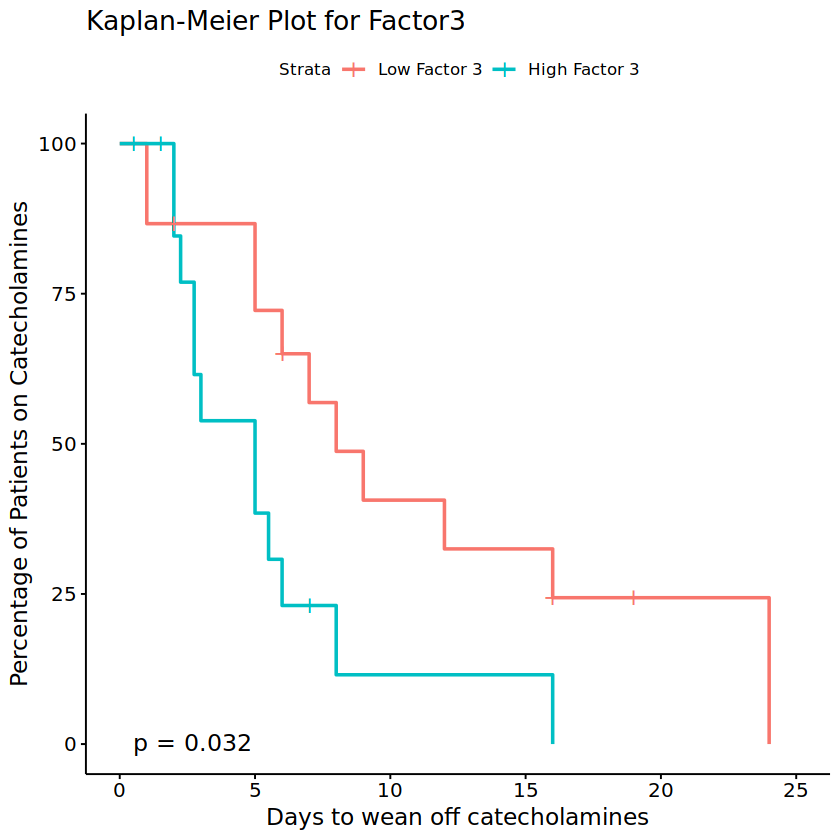

In [10]:
# Create a new column in df for stratifying patients based on the cutpoint
df$FactorCluster <- df$Factor3 > cut
print(df)
# Fit the Kaplan-Meier survival model, stratifying by the FactorCluster
fit <- survfit(Surv(time, event) ~ FactorCluster, data = df)
fit
summary(fit)
# Create the Kaplan-Meier plot
km_plot <- ggsurvplot(
  fit,
  data = df,
  conf.int = FALSE,  # Show confidence intervals
  pval = TRUE,      # Show p-value
  fun = function(y) y * 100,  # Transform y-axis to percentages
  legend = "top",
censor = TRUE,
  risk.table = TRUE,
  legend.labs = c("Low Factor 3", "High Factor 3"),  # Rename the legend labels
  xlab = "Days to wean off catecholamines",  # X-axis label
  ylab = "Percentage of Patients on Catecholamines",  # Y-axis label
  title = "Kaplan-Meier Plot for Factor3"  # Plot title
)

# Display the plot
km_plot$plot



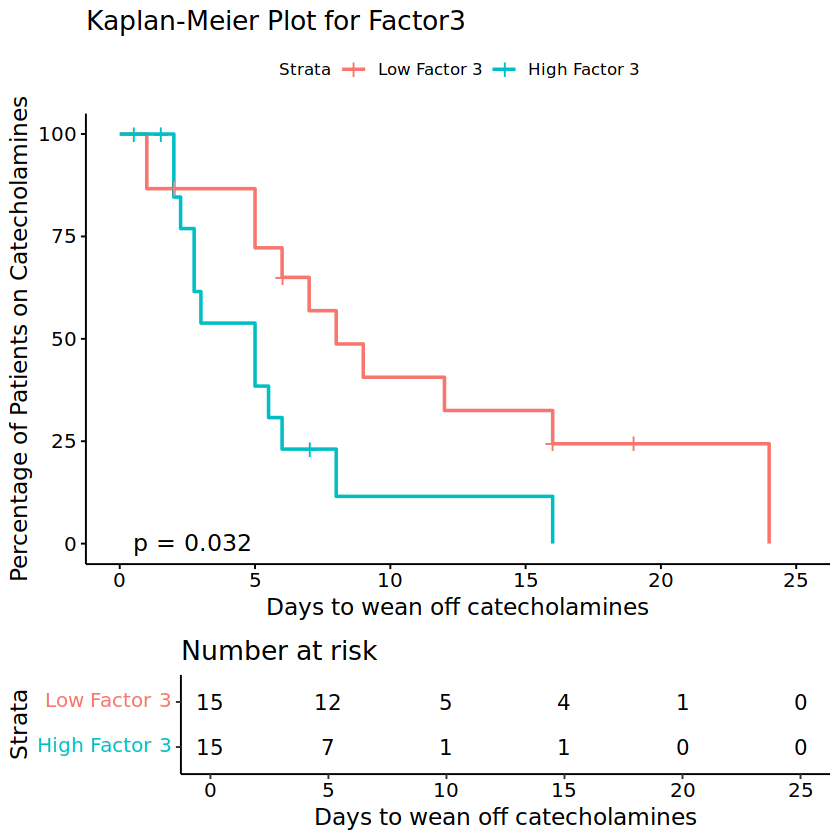

In [11]:
print(km_plot)

In [12]:
write.csv(df,"survival_analysis/kaplar_meier_groups_median.csv")

In [13]:
p = km_plot
pdf("survival_analysis/kaplar_meier_plot_median.pdf", width = 8, height = 6)
print(p)
dev.off()

png 
  2

In [30]:
sample_metda_data = read.csv("/ictstr01/home/icb/bhavishya.nelakuditi/mofa_workflow/input_data/Prepared_Sample_Meta_Data_TP1.csv")

In [31]:
surv_obj
head(sample_metda_data)
rownames(sample_metda_data) = sample_metda_data$sample_id
Z2 <- sample_metda_data[, c("Leukocyte", "CRP")]
Z2 = Z2[rownames(sample_data),]
# Combine the columns into a new matrix/data frame Z3
Z1 <- get_factors(MOFAobject)[[1]]
Z1 = as.data.frame(Z1)
Z1 = Z1[rownames(sample_data),]
head(Z1)
head(Z2)

 [1]  5.00   9.00   5.00  24.00  19.00+  6.00   1.00   8.00   2.00+  7.00 
[11]  3.00  16.00   6.00+ 16.00+  7.00+ 12.00   0.50+  5.00   1.00   6.00 
[21]  1.50+  8.00   2.75   2.25   2.75   2.00   5.00  16.00   5.50   2.00 

,sample_id,catecholamine_risk,lactate_clearance,risk,LVEF_admission,catecholamines_days,catecholamines,mortality,organ_failure,organ_support,⋯,CRP,Leukocyte,Troponin.T,Plt.Count,IL.6,Lactate,NTproBNP,CK,CK.MB,Crea
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<lgl>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<dbl>
1,KS1.1,,good,high_risk,20,NA,FALSE,no,no,yes_organ_support,⋯,6.8,13.80,NA,320,15.2,2.9,NA,53,NA,0.6
2,KS2.1,good,good,high_risk,NA,5,TRUE,no,yes_organ_failure,yes_organ_support,⋯,5.5,12.00,0.049,134,46.5,3.1,7068,276,18,2.1
3,KS3.1,bad_catecholamine_risk,bad_lactate,high_risk,15,9,TRUE,no,yes_organ_failure,yes_organ_support,⋯,4.0,12.20,0.167,343,17.3,3.4,NA,57,NA,4.3
4,KS4.1,good,bad_lactate,high_risk,37,5,TRUE,no,no,yes_organ_support,⋯,4.5,21.30,9.970,221,111.0,5.9,NA,5019,796,1.0
5,KS5.1,bad_catecholamine_risk,bad_lactate,high_risk,15,24,TRUE,no,yes_organ_failure,yes_organ_support,⋯,15.6,9.33,8.940,174,42.8,2.5,NA,618,84,47.0
6,KS6.1,bad_catecholamine_risk,good,high_risk,27,19,TRUE,yes_died,yes_organ_failure,yes_organ_support,⋯,6.2,9.51,5.510,123,27.7,4.9,11365,1868,137,0.7


,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10,Factor11,Factor12,Factor13
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KS2.1,-1.1380215,-2.4001775,-0.9409006,0.49518650,-0.45735312,0.18023750,-0.39355104,0.1684339,-0.35048076,-0.74592985,-0.20013770,0.7033823,0.07461506
KS3.1,-1.0963783,0.5956438,-1.3060507,0.36298385,-0.74814601,-0.13221943,0.34942434,-0.3041452,0.01476078,0.09446782,0.28042469,-0.0542332,-0.12828674
KS4.1,0.6091119,-1.3292517,-0.2967570,-0.98782179,-1.34535766,0.02764428,0.01806907,-0.5809855,0.17379506,-0.27901697,-0.32303503,-0.3045434,0.49256595
KS5.1,0.4573529,-1.3759116,-1.1873740,-0.76904259,-1.23797308,0.02888216,-0.46318466,-0.3879959,-0.45226856,-0.39964627,-0.07083247,-0.5088787,0.53543327
KS6.1,-1.0924141,0.1895515,-1.4662732,0.02888548,-0.51428955,0.45264039,0.02716668,-0.6363335,0.03394731,-0.29720311,-0.04194084,0.2273836,-0.28063392
KS7.1,1.2275025,-1.1096987,-0.3112264,-0.06562599,-0.04171305,-0.03815253,-0.29800075,-0.9645618,0.20181429,0.02696544,-0.07564292,0.2107092,-0.12918649


,Leukocyte,CRP
,<dbl>,<dbl>
KS2.1,12.00,5.5
KS3.1,12.20,4.0
KS4.1,21.30,4.5
KS5.1,9.33,15.6
KS6.1,9.51,6.2
KS7.1,5.12,3.2


In [32]:
Z1 = as.data.frame(Z1$Factor3)
Z3 <- cbind(Z1,Z2)
Z = Z3
head(Z)

,Z1$Factor3,Leukocyte,CRP
,<dbl>,<dbl>,<dbl>
KS2.1,-0.9409006,12.00,5.5
KS3.1,-1.3060507,12.20,4.0
KS4.1,-0.2967570,21.30,4.5
KS5.1,-1.1873740,9.33,15.6
KS6.1,-1.4662732,9.51,6.2
KS7.1,-0.3112264,5.12,3.2


In [33]:
fit <- coxph(surv_obj ~ ., data = as.data.frame(Z))
print(fit)

Call:
coxph(formula = surv_obj ~ ., data = as.data.frame(Z))

                 coef exp(coef) se(coef)      z      p
`Z1$Factor3`  0.90923   2.48241  0.40796  2.229 0.0258
Leukocyte    -0.04292   0.95799  0.05283 -0.812 0.4166
CRP           0.01966   1.01985  0.04910  0.400 0.6889

Likelihood ratio test=6.75  on 3 df, p=0.08031
n= 30, number of events= 23 


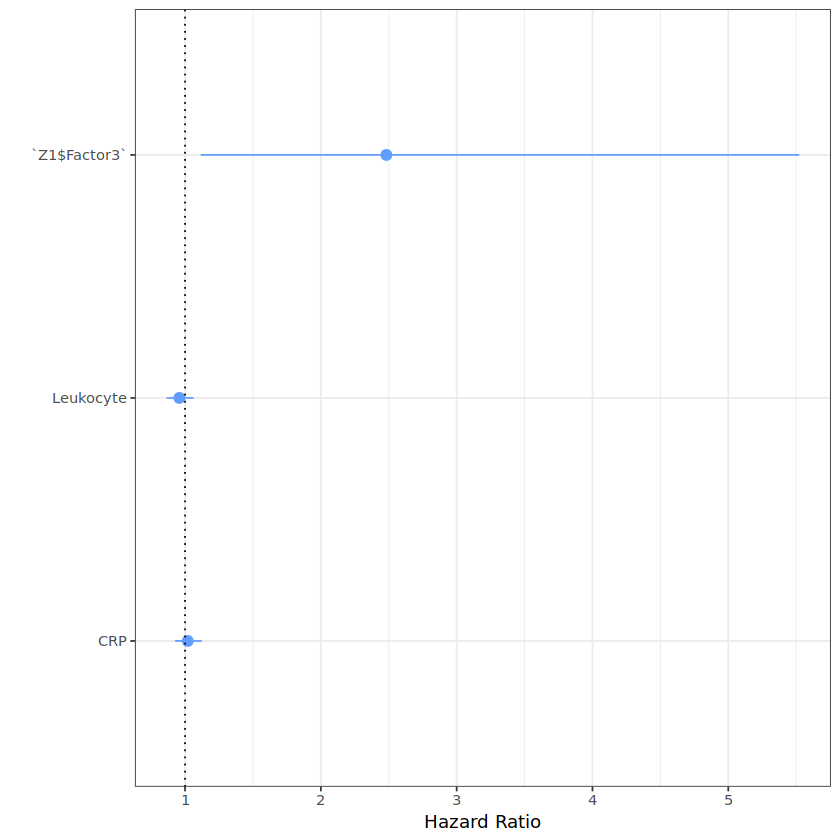

In [34]:
s <- summary(fit)
coef <- s[["coefficients"]]

df <- data.frame(
  factor = factor(rownames(coef), levels = rev(rownames(coef))),
  p      = coef[,"Pr(>|z|)"], 
  coef   = coef[,"exp(coef)"], 
  lower  = s[["conf.int"]][,"lower .95"],  # Make sure this matches exactly
  upper  = s[["conf.int"]][,"upper .95"]   # Note: changed 'higher' to 'upper' to match ggplot
)

# Then modify your ggplot to use 'upper' instead of 'higher'
p = ggplot(df, aes(x=factor, y=coef, ymin=lower, ymax=upper)) +  # Changed 'higher' to 'upper'
  geom_pointrange(col='#619CFF') + 
  coord_flip() +
  scale_x_discrete() + 
  labs(y="Hazard Ratio", x="") + 
  geom_hline(aes(yintercept=1), linetype="dotted") +
  theme_bw()

p

In [19]:
pdf("survival_analysis/hazard_ratio_plot.pdf", width = 8, height = 6)
print(p)
dev.off()


png 
  2

In [32]:
test.ph <- cox.zph(fit)
test.ph

               chisq df    p
`Z1$Factor1` 0.49926  1 0.48
Leukocyte    0.07222  1 0.79
CRP          0.00208  1 0.96
GLOBAL       1.00258  3 0.80

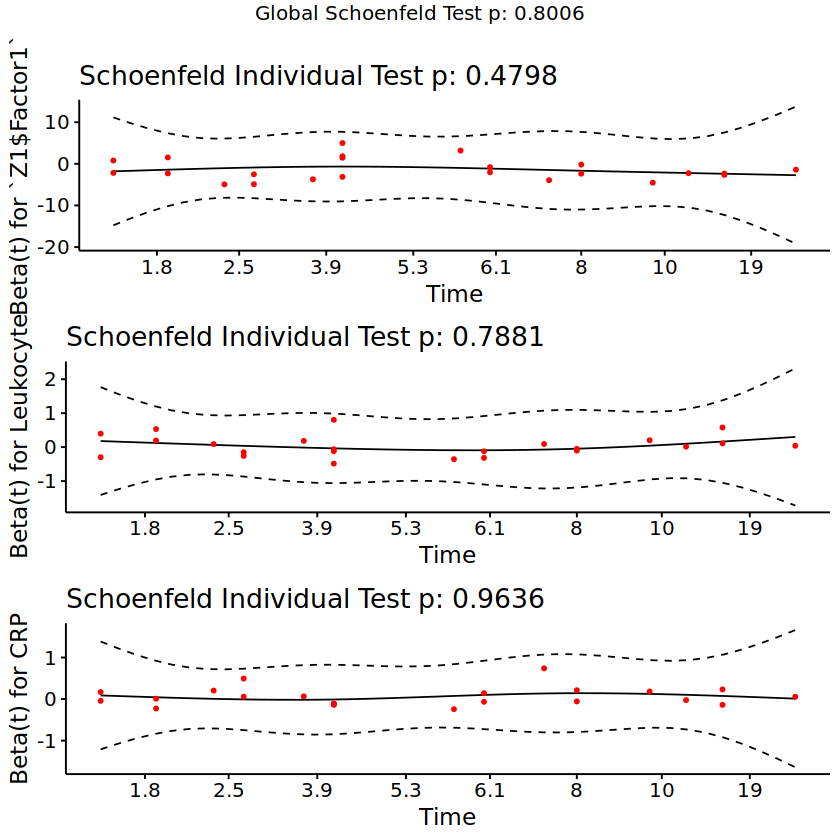

In [33]:
p = ggcoxzph(test.ph)
print(p)

In [22]:
pdf("survival_analysis/scaled_Schoenfeld_residuals_plot.pdf", width = 8, height = 6)
print(p)
dev.off()

png 
  2